## Algorithm / Overview — 2-Group 1D “Realistic” Slab Reactor (Three-Batch Core)

### Inputs and model definition
- Geometry is solved on the **half-domain** exploiting symmetry:
  - Core half-width: $a = 120\ \mathrm{cm}$
  - Reflector width: $b = 20\ \mathrm{cm}$
  - Domain: $x \in [0, a+b]$
- Uniform mesh: $\Delta x = 1\ \mathrm{cm}$.
- Each assembly is $20\ \mathrm{cm}\Rightarrow 20$ mesh cells.
- Loading pattern (half-core, center $\rightarrow$ boundary): $[3, 3, 2, 2, 1, 1, 4]$ with reflector ID $4$.
- Two-group macroscopic constants are **defined in the script**:  
  $D_g$, $\Sigma_{a,g}$, $\nu\Sigma_{f,g}$, $\kappa\Sigma_{f,g}$, and the scattering matrix $S_{g\to g'}$,  
  including **upscattering**.
- Power normalization target: $P_{\text{core}} = 90\ \mathrm{MW}$; assembly height $h = 400\ \mathrm{cm}$.

---

### Step 1 — Build the material map on the mesh
1. Convert the half-core assembly pattern into a **cell-wise material ID array**:
   - Assign 20 cells per assembly.
   - IDs 1–3 correspond to fuel regions; ID 4 is reflector.
2. For each cell $i$, store the corresponding two-group constants from `XS[ID_i]`.

---

### Step 2 — Discretize the 2-group diffusion equations (finite differences)
For each group $g \in \{1,2\}$, discretize on cell-centered unknowns $\phi_{g,i}$ using:
- Diffusion operator in 1D:
  $$
  -\frac{d}{dx}\left(D_g \frac{d\phi_g}{dx}\right)
  \ \Rightarrow\ 
  -\frac{D_{g,i+1/2}(\phi_{g,i+1}-\phi_{g,i}) - D_{g,i-1/2}(\phi_{g,i}-\phi_{g,i-1})}{\Delta x^2},
  $$
  with harmonic averaging at interfaces:
  $$
  D_{g,i+1/2}=\left[\frac{1}{2}\left(\frac{1}{D_{g,i}}+\frac{1}{D_{g,i+1}}\right)\right]^{-1}.
  $$
- Removal term $\Sigma_{r,g}\phi_{g}$ and group coupling through scattering are assembled such that
  **scattering is included on the LHS** (including upscattering):
  $$
  \Sigma_{r,g} = \Sigma_{a,g} + \sum_{g'\neq g} S_{g\to g'}.
  $$
This yields a sparse block linear system for the full unknown vector  
$\Phi=[\phi_{1,1},\ldots,\phi_{1,N},\phi_{2,1},\ldots,\phi_{2,N}]^T$:
$$
A\,\Phi = Q,
$$
where $A$ contains diffusion + removal + scattering couplings.

---

### Step 3 — Boundary conditions (half-domain)
- Symmetry at the core center $x=0$: **zero gradient** for each group
  $$
  \left.\frac{d\phi_g}{dx}\right|_{x=0}=0.
  $$
- Vacuum boundary at $x=a+b$: implemented  via ghost-cell elimination:
  $$
  \phi_g(L) + 2D_g(L)\left.\frac{d\phi_g}{dx}\right|_{L} = 0.
  $$

---

### Step 4 — Power iteration for $k_{\mathrm{eff}}$ and flux shape
1. Initialize $k^{(0)}=1$ and a positive flux guess $\Phi^{(0)}$.
2. For iteration $m$:
   - Compute the fission production term per cell:
     $$
     F_i^{(m)} = \sum_{g} \nu\Sigma_{f,g,i}\,\phi_{g,i}^{(m)}.
     $$
   - Build the fission source split into groups with $\chi$ (as implemented in the script):
     $$
     Q_{g,i}^{(m)} = \frac{1}{k^{(m)}}\,\chi_g\,F_i^{(m)}.
     $$
   - Solve the coupled linear system using a sparse direct solver:
     $$
     A\,\Phi^{(m+1)} = Q^{(m)} \qquad \text{(solved with `spsolve`)}.
     $$
   - Update the eigenvalue using a ratio of total fission production:
     $$
     k^{(m+1)} = k^{(m)}\,
     \frac{\sum_i F_i^{(m+1)}\,\Delta x}{\sum_i F_i^{(m)}\,\Delta x}.
     $$
   - Apply a numerical normalization to keep the flux bounded (e.g., divide by its max).
3. Converge when $|k^{(m+1)}-k^{(m)}| < 10^{-7}$.

---

### Step 5 — Physical normalization to $P_{\text{core}}=90\ \mathrm{MW}$
After convergence, scale the flux magnitude using $\kappa\Sigma_f$:
- Mesh-wise power:
  $$
  P_i = h\,\Delta x \sum_g \kappa\Sigma_{f,g,i}\,\phi_{g,i}.
  $$
- Total fission power (fuel cells only):
  $$
  P_{\text{fiss}} = \sum_{i\in\text{fuel}} P_i.
  $$
- Normalization factor and normalized flux:
  $$
  F_{\text{norm}} = \frac{P_{\text{core}}}{P_{\text{fiss}}},\qquad
  \phi_{g,i}^{\text{norm}} = F_{\text{norm}}\,\phi_{g,i}.
  $$

---

### Step 6 — Requested quantities and plots (initial pattern)
- Report:
  - $k_{\mathrm{eff}}$ (5 decimals),
  - peak power factor $\max(P_i^{\text{rel}})$ (2 decimals),
  - vessel fast flux $\phi_1^{\text{norm}}(x=L)$ at the **last reflector mesh point** (scientific, 2 decimals).
- Relative power:
  $$
  P_i^{\text{rel}} = \frac{P_i}{\overline{P}},\qquad
  \overline{P} = \frac{1}{N_{\text{fuel}}}\sum_{i\in\text{fuel}} P_i.
  $$
- Produce plots:
  - normalized fast and thermal fluxes $\phi_1(x)$, $\phi_2(x)$,
  - relative power distribution $P^{\text{rel}}(x)$.
- For full-core visualization, mirror the half-domain solution about $x=0$.

---

### Step 7 — Loading pattern optimization under constraints
1. Enumerate candidate half-core fuel patterns as the set of **unique permutations**
   of $[1,1,2,2,3,3]$, then append reflector ID $4$.
2. For each candidate:
   - run Steps 1–6 to obtain $k_{\mathrm{eff}}$, peaking, and vessel fast flux.
3. Keep candidates satisfying:
  $$
  \max(P^{\text{rel}}) < 3.0,\qquad \phi_{1,\text{vessel}} < 10^{13}\ \mathrm{n\ cm^{-2}\ s^{-1}}.
  $$
4. Select the “optimum” feasible pattern according to the script criterion (maximum $k_{\mathrm{eff}}$),
   and generate the corresponding plots and reported metrics.
5. Assign a descriptive name to the optimized pattern using the implemented heuristic
   (based on the radial trend of fuel IDs, e.g., “in-out” vs “out-in”).


Base case iterations: 71
Base case keff      : 1.21882
Peak power (rel)    : 2.44
Vessel fast flux    : 7.23e+13  n.cm^-2.s^-1

Solution check at x=10.5 cm:
phi1(10.5) = 1.705e+14  (expected ~1.705e14)
phi2(10.5) = 2.879e+13  (expected ~2.879e13)
Prel(10.5) = 5.886e-02       (expected ~5.886e-2)


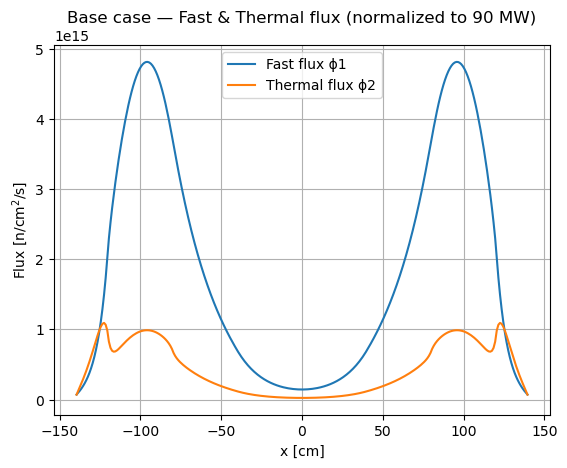

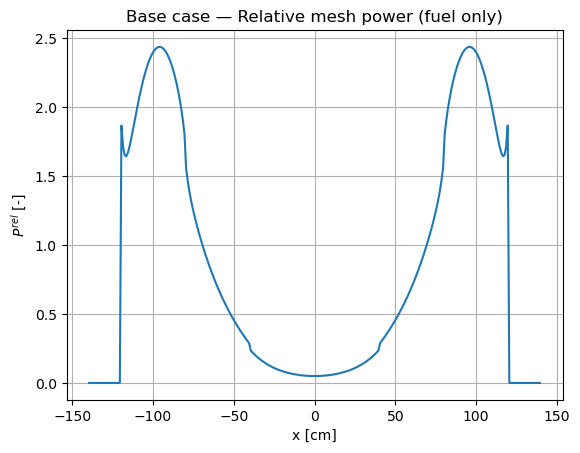

Total patterns tested : 90
Feasible patterns     : 19

Selected optimized pattern (half core + reflector):
[1, 2, 1, 2, 3, 3, 4]
Loading type: in-out (high-leakage)
Iterations  : 92
keff        : 1.26019
Peak (rel)  : 2.99
Vessel phi1 : 1.54e+12  n.cm^-2.s^-1


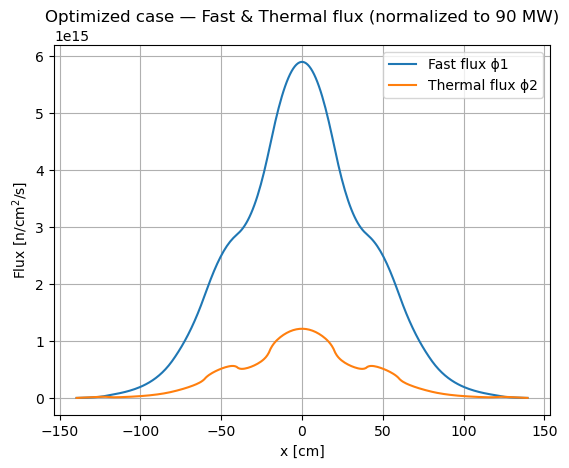

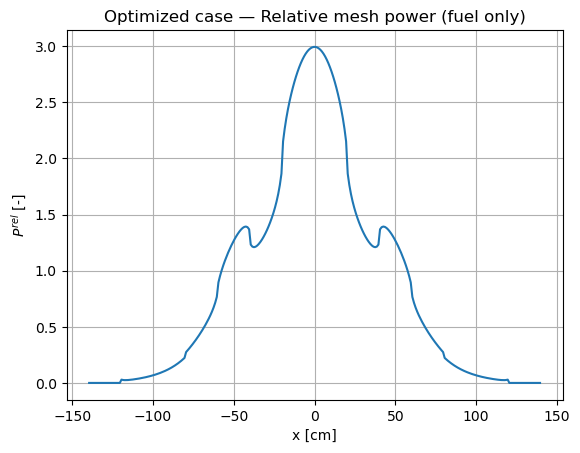

In [1]:
# Numerical Exercise IV — 1D two-group slab diffusion (core + reflector)
# Main steps: data/geometry -> discretization -> power iteration -> normalization -> metrics/plots.
# Each function below includes a docstring describing its purpose, inputs and outputs.


import numpy as np
from itertools import permutations
from scipy.sparse import lil_matrix, csc_matrix
from scipy.sparse.linalg import spsolve
import matplotlib.pyplot as plt
# --- Geometry & power normalization constants ---
dx = 1.0           # cm
a  = 120.0         # cm (half-core)
b  = 20.0          # cm (reflector thickness)
h  = 400.0         # cm (assembly height)
P_core_nom = 90e6  # W (full core power)

assembly_width = 20  # cm
cells_per_assembly = int(assembly_width/dx)

# Half-domain total length and number of cells
L_half = a + b
N = int(L_half/dx)  # total cells (core half + reflector)

# Cell-center coordinates in cm (half-domain)
x_half = (np.arange(N) + 0.5) * dx
# --- Cross section database (from the provided slide) ---
# Note: S[g_from, g_to]
XS = {
    1: dict(
        D   = [1.4824e+00, 3.8138e-01],
        Sa  = [9.6159e-03, 8.2153e-02],
        nusf= [7.1695e-03, 1.4038e-01],
        ksf = [9.1723e-14, 1.8644e-12],
        S   = [[1.9788e-01, 1.7369e-02],
               [1.6271e-03, 7.9024e-01]]
    ),
    2: dict(
        D   = [1.4854e+00, 3.7045e-01],
        Sa  = [1.0577e-02, 9.5616e-02],
        nusf= [6.0022e-03, 1.4267e-01],
        ksf = [7.4496e-14, 1.7873e-12],
        S   = [[1.9748e-01, 1.6350e-02],
               [1.8467e-03, 8.0234e-01]]
    ),
    3: dict(
        D   = [1.4850e+00, 3.6760e-01],
        Sa  = [1.1109e-02, 9.3004e-02],
        nusf= [5.1128e-03, 1.2765e-01],
        ksf = [6.1958e-14, 1.5497e-12],
        S   = [[1.9754e-01, 1.5815e-02],
               [1.8112e-03, 8.1197e-01]]
    ),
    4: dict(
        D   = [1.2000e+00, 4.0000e-01],
        Sa  = [1.0000e-03, 2.0000e-02],
        nusf= [0.0, 0.0],
        ksf = [0.0, 0.0],
        S   = [[2.5178e-01, 2.5000e-02],
               [0.0,        8.1333e-01]]
    ),
}

chi = np.array([1.0, 0.0])  # fission spectrum (all born fast)
def build_material_map(pattern_half):
    """
    Build the 1D material-ID map for the half-core geometry.
    
    The input loading pattern is given from the core center to the core boundary
    (half core). Each assembly spans `assembly_pitch` cm and is expanded into
    fine-mesh cells of size `dx`.
    
    Returns an integer array `mat` of length Ncells labeling each cell with the
    corresponding material ID (fuel batches and reflector).
    """

    # pattern_half: length 7 [6 core assemblies + reflector] or length 6 [core only]
    pattern_half = list(pattern_half)
    if len(pattern_half) == 6:
        pattern_half = pattern_half + [4]
    if len(pattern_half) != 7:
        raise ValueError("pattern_half must have 6 (core-only) or 7 (core+reflector) entries.")
    if pattern_half[-1] != 4:
        raise ValueError("Last entry must be reflector ID=4.")
    
    mat = np.empty(N, dtype=int)
    for j, aid in enumerate(pattern_half):
        mat[j*cells_per_assembly:(j+1)*cells_per_assembly] = aid
    return mat

# Provided initial pattern (half core + reflector)
pattern0 = [3, 3, 2, 2, 1, 1, 4]
mat0 = build_material_map(pattern0)
mat0[:25], mat0[-5:]
def harmonic(a, b):
    """
    Return the harmonic mean of two positive coefficients.
    
    Used for diffusion coefficients at cell interfaces:
    D_{i+1/2} = 2 D_i D_{i+1} / (D_i + D_{i+1}).
    """

    return 0.0 if (a + b) == 0.0 else 2.0*a*b/(a + b)

def assemble_system(mat, dx=1.0):
    """
    Assemble the linear system for 1D two-group diffusion on the half-domain.
    
    The discretization is finite-difference with variable diffusion coefficients
    (using harmonic averaging at interfaces). Down-scatter and up-scatter terms are
    moved to the left-hand side, resulting in a 2N-by-2N coupled system.
    
    Boundary conditions:
    - x = 0 (core center): symmetry (zero net current, dphi/dx = 0).
    - x = L (outer reflector boundary): vacuum condition,
      phi + 2 D dphi/dn = 0, implemented via ghost-cell elimination.
    
    Returns
    -------
    A : scipy.sparse.csc_matrix
        System matrix (size 2N x 2N).
    nusf : ndarray (2, N)
        nu*Sigma_f per group and cell.
    ksf : ndarray (2, N)
        kappa*Sigma_f per group and cell (for power normalization).
    """

    # Assemble sparse matrix A for coupled 2-group diffusion on the half-domain.
    # Unknown ordering: [phi_fast(0..N-1), phi_thermal(0..N-1)]
    Nloc = len(mat)
    D    = np.zeros((2, Nloc))
    Sa   = np.zeros((2, Nloc))
    nusf = np.zeros((2, Nloc))
    ksf  = np.zeros((2, Nloc))
    S    = np.zeros((2, 2, Nloc))  # S[from, to, i]
    
    for i, mid in enumerate(mat):
        d = XS[mid]
        D[:, i]    = d["D"]
        Sa[:, i]   = d["Sa"]
        nusf[:, i] = d["nusf"]
        ksf[:, i]  = d["ksf"]
        S[:, :, i] = np.array(d["S"], dtype=float)
    
    # Removal = absorption + outscatter to the other group
    Sr = np.zeros((2, Nloc))
    Sr[0, :] = Sa[0, :] + S[0, 1, :]
    Sr[1, :] = Sa[1, :] + S[1, 0, :]
    
    A = lil_matrix((2*Nloc, 2*Nloc))
    
    for g in range(2):
        for i in range(Nloc):
            row = g*Nloc + i
            diag = 0.0
            
            # Left side: symmetry at i=0 (zero current -> no left coupling)
            if i > 0:
                D_left = harmonic(D[g, i-1], D[g, i])
                A[row, g*Nloc + (i-1)] += -D_left/dx**2
                diag += D_left/dx**2
            
            # Right side: interior or vacuum boundary
            if i < Nloc - 1:
                D_right = harmonic(D[g, i], D[g, i+1])
                A[row, g*Nloc + (i+1)] += -D_right/dx**2
                diag += D_right/dx**2
            else:
                # Vacuum boundary: phi + 2D dphi/dn = 0 at x=L
                # Ghost cell elimination:
                D_right = D[g, i]
                beta = 2.0*D_right/dx
                ghost_coeff = - (0.5 - beta)/(0.5 + beta)  # phi_ghost = ghost_coeff * phi_last
                diag += (D_right/dx**2) * (1.0 - ghost_coeff)
            
            # Add diagonal terms
            A[row, row] += diag + Sr[g, i]
            
            # Scattering coupling on LHS (in-scatter moved to LHS)
            if g == 0:
                A[row, 1*Nloc + i] += -S[1, 0, i]  # -Sigma_s(2->1)*phi2
            else:
                A[row, 0*Nloc + i] += -S[0, 1, i]  # -Sigma_s(1->2)*phi1
    
    return csc_matrix(A), nusf, ksf
def fission_production(phi, nusf):
    """
    Compute the cell-wise fission production rate.
    
    For each cell i:
    F_i = sum_g (nu*Sigma_f)_{g,i} * phi_{g,i}.
    """

    # Cell-wise fission production: sum_g nusf_g * phi_g
    return (nusf * phi).sum(axis=0)

def build_fission_source(phi, nusf, chi):
    """
    Build the two-group fission source vector.
    
    Given the current flux estimate, compute the fission production and distribute
    it using the fission spectrum chi (chi_1 + chi_2 = 1).
    
    Returns q (shape 2N) to be used on the right-hand side A * phi = (1/keff) * q.
    """

    prod = fission_production(phi, nusf)
    q = np.zeros_like(phi)
    q[0, :] = chi[0] * prod
    q[1, :] = chi[1] * prod
    return q, prod

def power_iteration(A, nusf, chi, dx=1.0, tol_keff=1e-7, maxit=2000):
    """
    Solve the two-group eigenvalue problem by power iteration.
    
    Algorithm:
    1) Start from an initial flux guess and an initial keff.
    2) At each outer iteration, build the fission source from the current flux,
       solve the fixed-source problem, and update keff by the ratio of total
       fission productions between successive iterates.
    3) Normalize the flux to avoid overflow and repeat until |keff_{n+1}-keff_n|
       is below the specified tolerance.
    
    Returns keff, converged flux (shape 2N), and a convergence history.
    """

    Nloc = nusf.shape[1]
    phi = np.ones((2, Nloc))
    keff = 1.0
    
    q, prod_old = build_fission_source(phi, nusf, chi)
    Q_old = prod_old.sum() * dx
    
    for it in range(1, maxit+1):
        rhs = (q.reshape(-1) / keff)
        sol = spsolve(A, rhs)
        phi_new = sol.reshape((2, Nloc))
        
        _, prod_new = build_fission_source(phi_new, nusf, chi)
        Q_new = prod_new.sum() * dx
        
        # normalize to keep numbers stable (arbitrary normalization)
        phi_new /= Q_new
        
        keff_new = keff * (Q_new / Q_old)
        
        if abs(keff_new - keff) < tol_keff:
            return keff_new, phi_new, it
        
        phi = phi_new
        keff = keff_new
        q, prod_old = build_fission_source(phi, nusf, chi)
        Q_old = prod_old.sum() * dx
    
    raise RuntimeError("Power iteration did not converge within maxit.")
def normalize_to_power(phi, mat, ksf, dx=1.0, h=400.0, P_core_nom=90e6):
    """
    Scale the flux so that the total core power equals P_core.
    
    The power density is computed as:
    p(x) = sum_g kappa_g * Sigma_{f,g}(x) * phi_g(x)    [W/cm^3]
    The total power is obtained by integrating over the full core volume:
    P = (2 * core_height) * integral_core p(x) dA_1D,
    where the factor 2 accounts for symmetry (half-core solved).
    
    Returns the scaled flux and the applied scaling factor.
    """

    # Compute full-core power from half-core (symmetry factor 2) and scale phi accordingly.
    P_mesh_half = h * dx * (ksf * phi).sum(axis=0)
    P_half = P_mesh_half.sum()
    P_full = 2.0 * P_half
    
    Fn = P_core_nom / P_full
    phi_norm = Fn * phi
    P_mesh_half_norm = Fn * P_mesh_half
    return phi_norm, P_mesh_half_norm, Fn, P_full

def relative_power(P_mesh_half_norm, mat, P_core_nom=90e6):
    """
    Compute the relative (dimensionless) power shape in the core.
    
    The local power is evaluated from kappa*Sigma_f*phi, restricted to the core
    region. The result is normalized by the average core power so that the mean of
    p_rel over the core is 1.
    """

    fuel_mask = (mat != 4)
    N_fuel_half = fuel_mask.sum()
    N_fuel_full = 2 * N_fuel_half
    Pavg = P_core_nom / N_fuel_full
    
    Prel = np.zeros_like(P_mesh_half_norm)
    Prel[fuel_mask] = P_mesh_half_norm[fuel_mask] / Pavg
    return Prel

def metrics(phi_norm, Prel, mat):
    """
    Compute the key performance metrics requested in the exercise.
    
    Outputs:
    - keff
    - peak power peaking factor (max(p_rel))
    - vessel fast flux (fast-group flux at the last reflector mesh point)
    """

    fuel_mask = (mat != 4)
    peak = Prel[fuel_mask].max()
    vessel_fast = phi_norm[0, -1]  # last reflector mesh point
    return peak, vessel_fast

def mirror_half_to_full(x_half, arr_half):
    # Mirror arrays to full symmetric domain.
    x_full = np.concatenate((-x_half[::-1], x_half))
    if arr_half.ndim == 1:
        arr_full = np.concatenate((arr_half[::-1], arr_half))
    else:
        arr_full = np.concatenate((arr_half[:, ::-1], arr_half), axis=1)
    return x_full, arr_full
# --- Solve base case ---
A0, nusf0, ksf0 = assemble_system(mat0, dx=dx)
keff0, phi0, it0 = power_iteration(A0, nusf0, chi, dx=dx, tol_keff=1e-7)

phi0_norm, Pmesh0_norm_half, _, _ = normalize_to_power(phi0, mat0, ksf0, dx=dx, h=h, P_core_nom=P_core_nom)
Prel0 = relative_power(Pmesh0_norm_half, mat0, P_core_nom=P_core_nom)
peak0, vessel_fast0 = metrics(phi0_norm, Prel0, mat0)

print(f"Base case iterations: {it0:d}")
print(f"Base case keff      : {keff0:.5f}")
print(f"Peak power (rel)    : {peak0:.2f}")
print(f"Vessel fast flux    : {vessel_fast0:.2e}  n.cm^-2.s^-1")

# --- Solution check at x = 10.5 cm (cell center) ---
# With dx=1 cm and cell centers at 0.5, 1.5, ... => x=10.5 corresponds to i=10
i_check = int(10.5/dx - 0.5)
print("\nSolution check at x=10.5 cm:")
print(f"phi1(10.5) = {phi0_norm[0,i_check]:.3e}  (expected ~1.705e14)")
print(f"phi2(10.5) = {phi0_norm[1,i_check]:.3e}  (expected ~2.879e13)")
print(f"Prel(10.5) = {Prel0[i_check]:.3e}       (expected ~5.886e-2)")
# --- Plots base case (full domain) ---
x_full, phi0_full = mirror_half_to_full(x_half, phi0_norm)
_, Prel0_full = mirror_half_to_full(x_half, Prel0)

plt.figure()
plt.plot(x_full, phi0_full[0, :], label="Fast flux ϕ1")
plt.plot(x_full, phi0_full[1, :], label="Thermal flux ϕ2")
plt.xlabel("x [cm]")
plt.ylabel(r"Flux [n/cm$^2$/s]")
plt.title("Base case — Fast & Thermal flux (normalized to 90 MW)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(x_full, Prel0_full)
plt.xlabel("x [cm]")
plt.ylabel(r"$P^{rel}$ [-]")
plt.title("Base case — Relative mesh power (fuel only)")
plt.grid(True)
plt.show()

def solve_pattern(core_pattern_half):
    """
    Solve the two-group slab problem for a given loading pattern.
    
    This is a convenience wrapper that:
    - builds the material map,
    - assembles the system,
    - performs power iteration for keff and flux,
    - normalizes to total core power,
    - computes p_rel and the requested metrics,
    - generates the requested plots.
    """

    # core_pattern_half: length 6 (core only, from center to boundary)
    pattern_half = list(core_pattern_half) + [4]
    mat = build_material_map(pattern_half)
    
    A, nusf, ksf = assemble_system(mat, dx=dx)
    keff, phi, it = power_iteration(A, nusf, chi, dx=dx, tol_keff=1e-7)
    
    phi_norm, Pmesh_norm_half, _, _ = normalize_to_power(phi, mat, ksf, dx=dx, h=h, P_core_nom=P_core_nom)
    Prel = relative_power(Pmesh_norm_half, mat, P_core_nom=P_core_nom)
    peak, vessel_fast = metrics(phi_norm, Prel, mat)
    
    return dict(pattern=pattern_half, keff=keff, peak=peak, vessel_fast=vessel_fast, it=it,
                phi_norm=phi_norm, Prel=Prel, mat=mat)

def classify_loading(pattern_half_core_only):
    """
    Classify a loading pattern by its qualitative shape.
    
    Used to provide a human-readable name for the optimized pattern
    (e.g., 'out-in', 'in-out', or 'mixed'), based on enrichment/burnup ordering.
    """

    # Simple naming heuristic:
    # If IDs increase outward (more burned fuel at the periphery) -> "in-out (high-leakage)"
    # If IDs decrease outward (fresher at periphery) -> "low-leakage (out-in)"
    p = np.array(pattern_half_core_only, dtype=float)
    slope = np.polyfit(np.arange(len(p)), p, 1)[0]
    return "in-out (high-leakage)" if slope > 0 else "low-leakage (out-in)"

# --- Brute-force search over unique permutations (90) ---
base = [1,1,2,2,3,3]
unique_patterns = sorted(set(permutations(base)))

peak_max = 3.0
vessel_fast_max = 1e13

feasible = []
all_results = []

for p in unique_patterns:
    r = solve_pattern(p)
    all_results.append(r)
    if (r["peak"] < peak_max) and (r["vessel_fast"] < vessel_fast_max):
        feasible.append(r)

print(f"Total patterns tested : {len(all_results)}")
print(f"Feasible patterns     : {len(feasible)}")

best = max(feasible, key=lambda r: r["keff"])
best_core_only = best["pattern"][:-1]

print("\nSelected optimized pattern (half core + reflector):")
print(best["pattern"])
print(f"Loading type: {classify_loading(best_core_only)}")
print(f"Iterations  : {best['it']}")
print(f"keff        : {best['keff']:.5f}")
print(f"Peak (rel)  : {best['peak']:.2f}")
print(f"Vessel phi1 : {best['vessel_fast']:.2e}  n.cm^-2.s^-1")
# --- Plots optimized case (full domain) ---
x_full, phi_opt_full = mirror_half_to_full(x_half, best["phi_norm"])
_, Prel_opt_full = mirror_half_to_full(x_half, best["Prel"])

plt.figure()
plt.plot(x_full, phi_opt_full[0, :], label="Fast flux ϕ1")
plt.plot(x_full, phi_opt_full[1, :], label="Thermal flux ϕ2")
plt.xlabel("x [cm]")
plt.ylabel(r"Flux [n/cm$^2$/s]")
plt.title("Optimized case — Fast & Thermal flux (normalized to 90 MW)")
plt.grid(True)
plt.legend()
plt.show()

plt.figure()
plt.plot(x_full, Prel_opt_full)
plt.xlabel("x [cm]")
plt.ylabel(r"$P^{rel}$ [-]")
plt.title("Optimized case — Relative mesh power (fuel only)")
plt.grid(True)
plt.show()